W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
① 시도별 경제활동별 지역내총생산 파일 업로드


Saving 시도별_경제활동별_지역내총생산_20260621210952.xlsx to 시도별_경제활동별_지역내총생산_20260621210952 (3).xlsx

② 시도별 전출입(순이동자수) 파일 업로드


Saving 전출지_전입지_시도_별_이동자수_20260621211106.xlsx to 전출지_전입지_시도_별_이동자수_20260621211106 (3).xlsx


상관관계 분석
상관계수 : 0.1248


/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


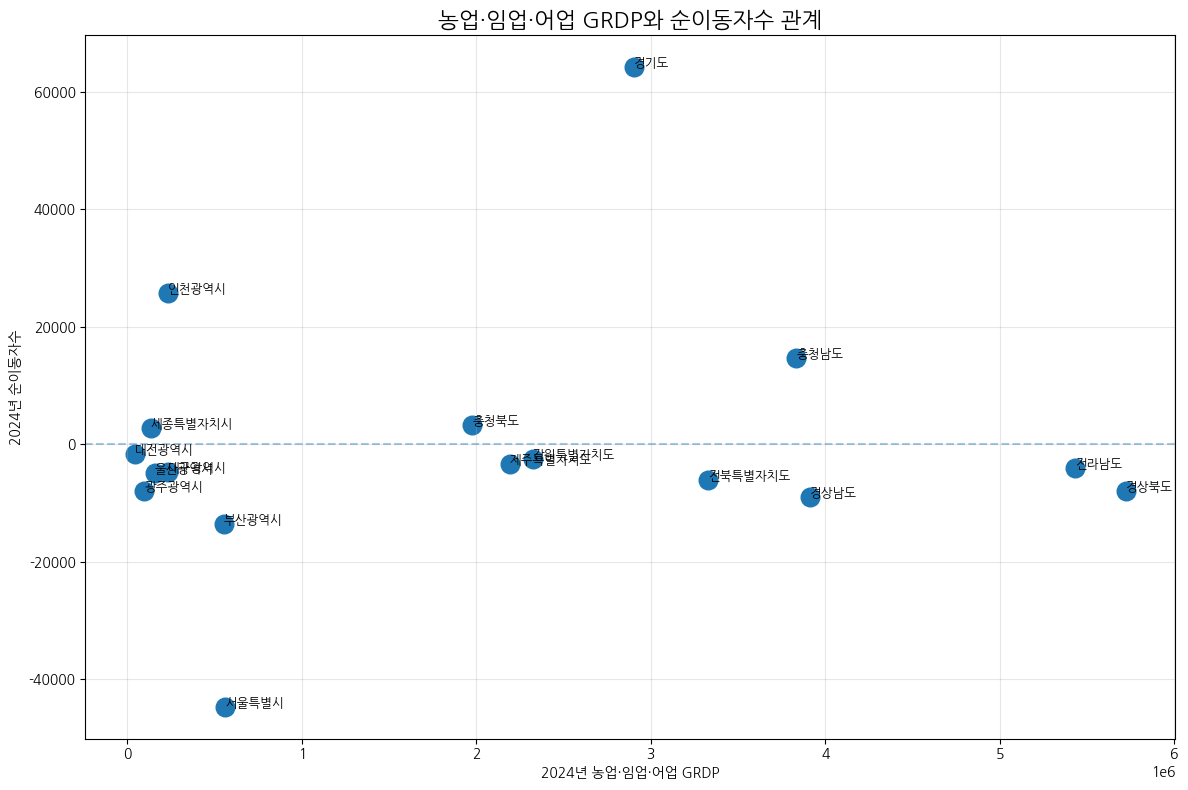



인구 유입 증가 TOP 3
1. 경기도 | 순이동자수 : 64,218 | 농업·임업·어업 GRDP : 2,905,281
2. 인천광역시 | 순이동자수 : 25,643 | 농업·임업·어업 GRDP : 234,484
3. 충청남도 | 순이동자수 : 14,664 | 농업·임업·어업 GRDP : 3,834,178


인구 감소 TOP 3
1. 서울특별시 | 순이동자수 : -44,692 | 농업·임업·어업 GRDP : 562,248
2. 부산광역시 | 순이동자수 : -13,657 | 농업·임업·어업 GRDP : 553,765
3. 경상남도 | 순이동자수 : -9,069 | 농업·임업·어업 GRDP : 3,909,245


전체 분석 데이터


,지역,GRDP,순이동자수
8,경기도,2905281,64218
3,인천광역시,234484,25643
11,충청남도,3834178,14664
10,충청북도,1977386,3245
7,세종특별자치시,134907,2808
5,대전광역시,43014,-1693
9,강원특별자치도,2322455,-2527
16,제주특별자치도,2190255,-3361
13,전라남도,5430983,-3988
2,대구광역시,231372,-4712


In [6]:
# ============================================================
# 농업·임업·어업 GRDP와 순이동자수 관계 분석
# ============================================================

!apt-get -qq update
!apt-get -qq install -y fonts-nanum

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

from google.colab import files

# ============================================================
# 한글 폰트
# ============================================================

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)

plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

# ============================================================
# 1. GRDP 파일 업로드
# ============================================================

print("="*60)
print("① 시도별 경제활동별 지역내총생산 파일 업로드")
print("="*60)

uploaded = files.upload()
grdp_file = list(uploaded.keys())[0]

# ============================================================
# 2. 순이동자수 파일 업로드
# ============================================================

print("\n" + "="*60)
print("② 시도별 전출입(순이동자수) 파일 업로드")
print("="*60)

uploaded = files.upload()
move_file = list(uploaded.keys())[0]

# ============================================================
# 3. GRDP 읽기
# ============================================================

grdp_raw = pd.read_excel(
    grdp_file,
    header=None
)

grdp = grdp_raw.iloc[2:19, :12].copy()

grdp.columns = [
    "지역",
    "산업",
    "2015",
    "2016",
    "2017",
    "2018",
    "2019",
    "2020",
    "2021",
    "2022",
    "2023",
    "2024"
]

grdp["GRDP"] = pd.to_numeric(
    grdp["2024"],
    errors="coerce"
)

grdp = grdp[
    ["지역","GRDP"]
]

# ============================================================
# 4. 순이동자수 읽기
# ============================================================

move_raw = pd.read_excel(
    move_file,
    header=None
)

move = move_raw.iloc[2:19, :12].copy()

move.columns = [
    "전출지",
    "지역",
    "2015",
    "2016",
    "2017",
    "2018",
    "2019",
    "2020",
    "2021",
    "2022",
    "2023",
    "2024"
]

move["순이동자수"] = pd.to_numeric(
    move["2024"],
    errors="coerce"
)

move = move[
    ["지역","순이동자수"]
]

# ============================================================
# 5. 병합
# ============================================================

df = pd.merge(
    grdp,
    move,
    on="지역",
    how="inner"
)

# ============================================================
# 6. 상관계수
# ============================================================

corr = df["GRDP"].corr(
    df["순이동자수"]
)

print("\n")
print("="*60)
print("상관관계 분석")
print("="*60)
print(f"상관계수 : {corr:.4f}")

# ============================================================
# 7. 산점도
# ============================================================

plt.figure(figsize=(12,8))

plt.scatter(
    df["GRDP"],
    df["순이동자수"],
    s=180
)

for _, row in df.iterrows():

    plt.annotate(
        row["지역"],
        (
            row["GRDP"],
            row["순이동자수"]
        ),
        fontsize=9
    )

plt.axhline(
    0,
    linestyle="--",
    alpha=0.4
)

plt.title(
    "농업·임업·어업 GRDP와 순이동자수 관계",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("2024년 농업·임업·어업 GRDP")
plt.ylabel("2024년 순이동자수")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

# ============================================================
# 8. 인구 유입 TOP3
# ============================================================

top_in = (
    df.sort_values(
        "순이동자수",
        ascending=False
    )
    .head(3)
)

# ============================================================
# 9. 인구 감소 TOP3
# ============================================================

top_out = (
    df.sort_values(
        "순이동자수",
        ascending=True
    )
    .head(3)
)

# ============================================================
# 10. 결과 출력
# ============================================================

print("\n")
print("="*60)
print("인구 유입 증가 TOP 3")
print("="*60)

for i, row in enumerate(
    top_in.itertuples(),
    1
):
    print(
        f"{i}. {row.지역}"
        f" | 순이동자수 : {row.순이동자수:,.0f}"
        f" | 농업·임업·어업 GRDP : {row.GRDP:,.0f}"
    )

print("\n")
print("="*60)
print("인구 감소 TOP 3")
print("="*60)

for i, row in enumerate(
    top_out.itertuples(),
    1
):
    print(
        f"{i}. {row.지역}"
        f" | 순이동자수 : {row.순이동자수:,.0f}"
        f" | 농업·임업·어업 GRDP : {row.GRDP:,.0f}"
    )

# ============================================================
# 11. 전체 데이터
# ============================================================

print("\n")
print("="*60)
print("전체 분석 데이터")
print("="*60)

display(
    df.sort_values(
        "순이동자수",
        ascending=False
    )
)